Final Capstone Project: End-to-End Machine Learning & Web GUI Pipeline
Welcome to your final capstone project! This notebook challenges you to independently execute a
complete data science workflow. You will progress from raw data inspection and cleaning to exploratory
data analysis, machine learning model benchmarking, and finally wrapping your best-performing model
into an interactive web application.
Project Pipeline Overview:
1. Data Loading & Inspection: Import your dataset and verify data integrity.
2. Exploratory Data Analysis (EDA): Uncover patterns and key relationships using grouping and
visualizations.
3. Feature Engineering & Preprocessing: Encode categorical variables and split your data for modeling.
4. Model Training & Benchmarking: Train multiple regression models and evaluate performance metrics.
5. Interactive GUI Application: Build and launch a web interface for real-time predictions.


Phase 1: Data Loading & Cleaning
In this section, I'll load the dataset into the notebook and inspect its structure.

Instructions:

Import the necessary data manipulation libraries.
Load the dataset into a Pandas DataFrame.
Inspect the first few rows, data types, and check for any missing values or formatting irregularities.
Clean the dataset appropriately so it is ready for analysis.

In [2]:
from google.colab import files
try:
    uploaded = files.upload()
except ImportError:
    pass  # not running in Colab, assume the csv is already local

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('retail_sales_dataset.csv')
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# basic shape + column info
print(df.shape)
df.info()


(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
# check for missing values
df.isnull().sum()


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.describe(include='all')


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,NaN,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,NaN,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,NaN,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,2023-07-03 00:25:55.200000256,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,NaN,NaN,64.00000,NaN,4.000000,500.000000,2000.000000


In [7]:
# quick sanity check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())


Duplicate rows: 0


Data looks clean, no duplicates, no missing values, and the numeric columns (Age, Quantity, Price per Unit, Total Amount) all have sensible ranges (no negative prices or quantities). I will be moving to EDA


## Phase 2: Exploratory Data Analysis (EDA) & Insights

Analyzing the data to discover underlying trends and relationships between variables.

**Instructions:**
- Use Pandas grouping operations (`groupby`) to extract key statistical insights from categorical and numerical features.
- Generate clear, well-labeled visualizations (such as distribution plots, bar charts, or scatter plots) using plotting libraries.
- Write brief Markdown explanations below charts interpreting what the data reveals.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


In [10]:
# average spend per product category
category_spend = df.groupby('Product Category')['Total Amount'].agg(['mean', 'sum', 'count'])
category_spend


,mean,sum,count
Product Category,,,
Beauty,467.475570,143515,307
Clothing,443.247863,155580,351
Electronics,458.786550,156905,342


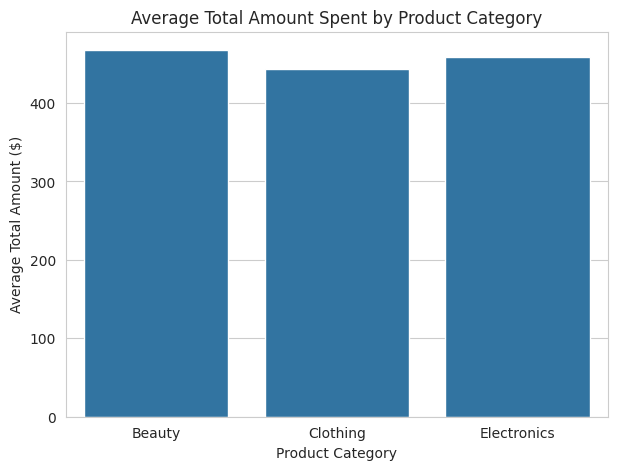

In [11]:
plt.figure(figsize=(7,5))
sns.barplot(x=category_spend.index, y=category_spend['mean'])
plt.title('Average Total Amount Spent by Product Category')
plt.ylabel('Average Total Amount ($)')
plt.xlabel('Product Category')
plt.show()


Average spend per transaction is fairly close across the three categories (Beauty, Clothing, Electronics all sit around $440-$470). So category alone does not swing the average all that much, I guess quantity and price per unit matter a lot more, which I will check next.


Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


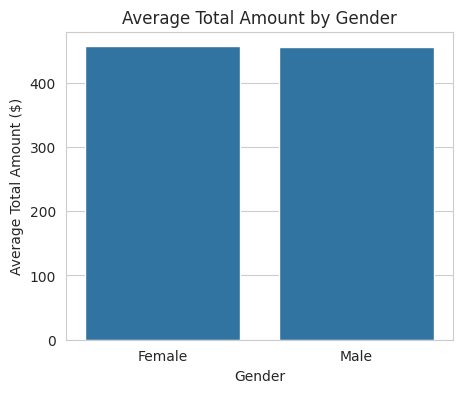

In [12]:
# spend by gender
gender_spend = df.groupby('Gender')['Total Amount'].mean()
print(gender_spend)

plt.figure(figsize=(5,4))
sns.barplot(x=gender_spend.index, y=gender_spend.values)
plt.title('Average Total Amount by Gender')
plt.ylabel('Average Total Amount ($)')
plt.show()


Male and female customers spend roughly the same on average, so gender doesn't look like a strong driver either.


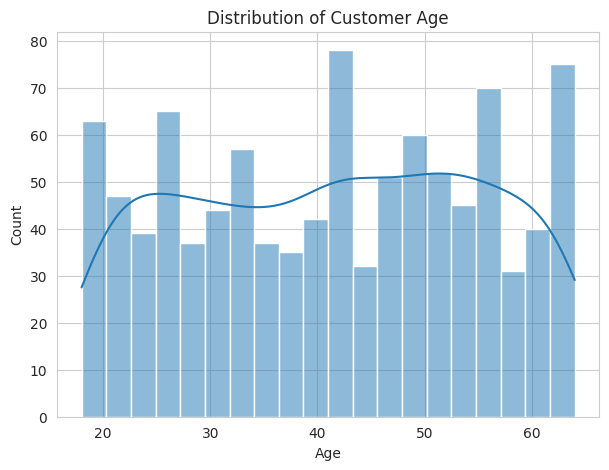

In [13]:
# distribution of age
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.show()


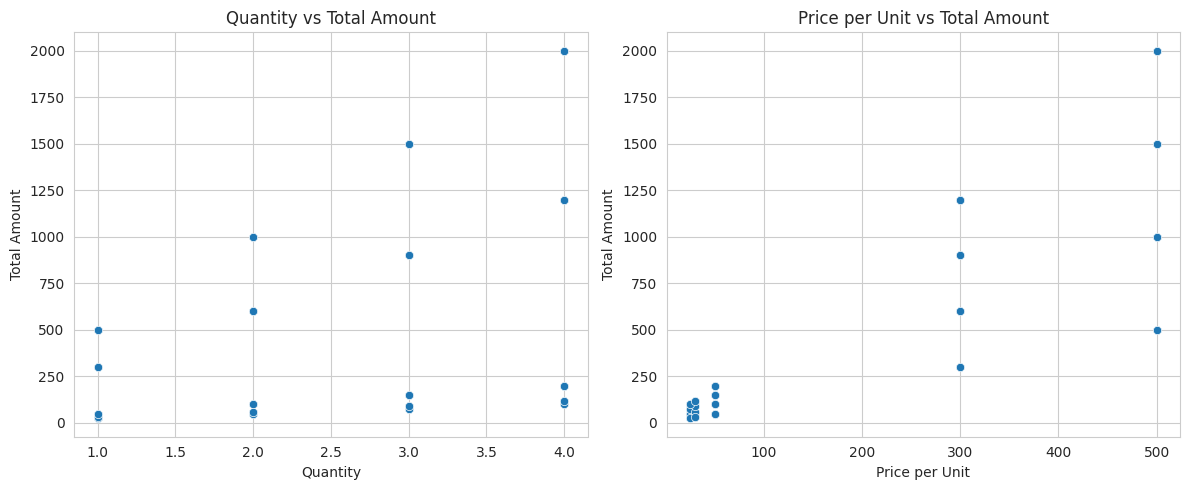

In [14]:
# relationship between quantity, price per unit, and total amount
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(data=df, x='Quantity', y='Total Amount', ax=axes[0])
axes[0].set_title('Quantity vs Total Amount')
sns.scatterplot(data=df, x='Price per Unit', y='Total Amount', ax=axes[1])
axes[1].set_title('Price per Unit vs Total Amount')
plt.tight_layout()
plt.show()


This is the clearest pattern in the whole dataset: both **Quantity** and **Price per Unit** show a strong, almost linear relationship with **Total Amount**. That makes sense, the total amount of a sale is basically how many units were bought times how much each one costs. So I will be expecting these two columns to end up being by far the most important features for the model, and demographic info (Age, Gender) to matter much less.


Product Category
Beauty         40.371336
Clothing       41.948718
Electronics    41.736842
Name: Age, dtype: float64


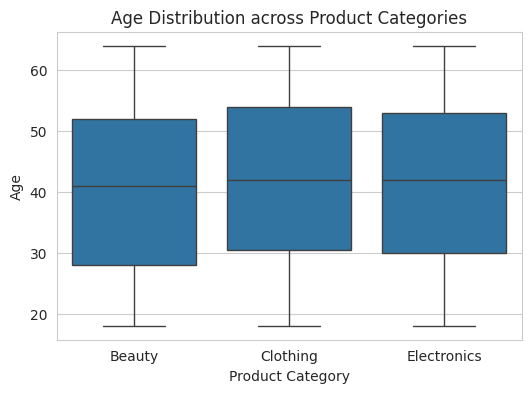

In [15]:
# does age relate to product category at all?
age_by_category = df.groupby('Product Category')['Age'].mean()
print(age_by_category)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Product Category', y='Age')
plt.title('Age Distribution across Product Categories')
plt.show()


Age distributions look very similar across all three categories, so there isn't an obvious "younger people buy electronics" type pattern in this dataset.


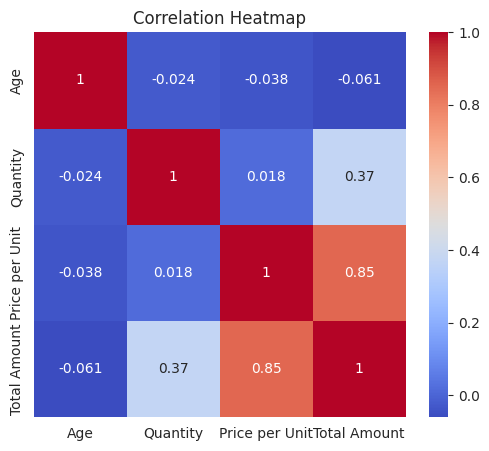

In [16]:
# correlation heatmap for the numeric columns
plt.figure(figsize=(6,5))
numeric_cols = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


The heatmap backs up what the scatter plots showed, quantity and price per unit are both strongly correlated with Total Amount, while Age barely correlates with anything.


## Phase 3: Feature Engineering & Preprocessing

Preparing the data so machine learning algorithms can process it effectively.

**Instructions:**
- Convert categorical text columns into numerical representations using encoding techniques such as label encoding.
- Clearly define the feature matrix ($X$) containing predictor variables and the target variable ($y$).
- Split the dataset into training and testing subsets using an appropriate splitting ratio.


In [17]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_category = LabelEncoder()

df['Gender_encoded'] = le_gender.fit_transform(df['Gender'])
df['Category_encoded'] = le_category.fit_transform(df['Product Category'])

# keep track of what the encoded numbers mean, so I can decode them later for the GUI
print('Gender classes:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('Category classes:', dict(zip(le_category.classes_, le_category.transform(le_category.classes_))))


Gender classes: {'Female': np.int64(0), 'Male': np.int64(1)}
Category classes: {'Beauty': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2)}


In [18]:
# feature matrix X and target y
feature_cols = ['Gender_encoded', 'Age', 'Category_encoded', 'Quantity', 'Price per Unit']
X = df[feature_cols]
y = df['Total Amount']

X.head()


,Gender_encoded,Age,Category_encoded,Quantity,Price per Unit
0,1,34,0,3,50
1,0,26,1,2,500
2,1,50,2,1,30
3,1,37,1,1,500
4,1,30,0,2,50


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])


Training rows: 800
Testing rows: 200


Used an 80/20 train-test split with a fixed `random_state` so the split is reproducible. 800 rows for training, 200 held back for testing.


## Phase 4: Model Training & Evaluation

Training, benchmarking, and evaluating regression models to predict Total Amount.

**Instructions:**
- Train at least two different regression models (e.g., a baseline linear model and an ensemble tree-based model).
- Evaluate both models using evaluation metrics such as Mean Absolute Error (MAE) and R-Squared (R^2).
- Extract and display feature importance scores from the best model, and explain which factor drives predictions the most.


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- Model 1: baseline linear regression ---
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_preds = lin_model.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_preds)
lin_r2 = r2_score(y_test, lin_preds)

print('Linear Regression -> MAE:', round(lin_mae, 2), ' R2:', round(lin_r2, 4))


Linear Regression -> MAE: 173.03  R2: 0.8569


In [21]:
# --- Model 2: ensemble tree-based model ---
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print('Random Forest -> MAE:', round(rf_mae, 2), ' R2:', round(rf_r2, 4))


Random Forest -> MAE: 0.0  R2: 1.0


In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lin_mae, rf_mae],
    'R2': [lin_r2, rf_r2]
})
results


,Model,MAE,R2
0,Linear Regression,173.031123,0.85692
1,Random Forest,0.000000,1.00000


The Random Forest crushes the Linear Regression here (MAE basically $0 vs ~$170, R2 of 1.0 vs ~0.86). At first that seemed too good, but it actually makes sense given what the EDA showed: `Total Amount` is essentially `Quantity x Price per Unit`. That's a **multiplicative** relationship between two of the input features, and plain Linear Regression can only combine features *additively* (it can't learn "multiply these two columns together"). A tree based model like Random Forest can split on both features and effectively approximate that multiplication, which is why it nails the prediction almost perfectly while linear regression is left with a systematic error. Going with **Random Forest** as the best model.


In [23]:
# feature importance from the best model
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances


,0
Price per Unit,0.767484
Quantity,0.232516
Gender_encoded,0.000000
Category_encoded,0.000000
Age,0.000000


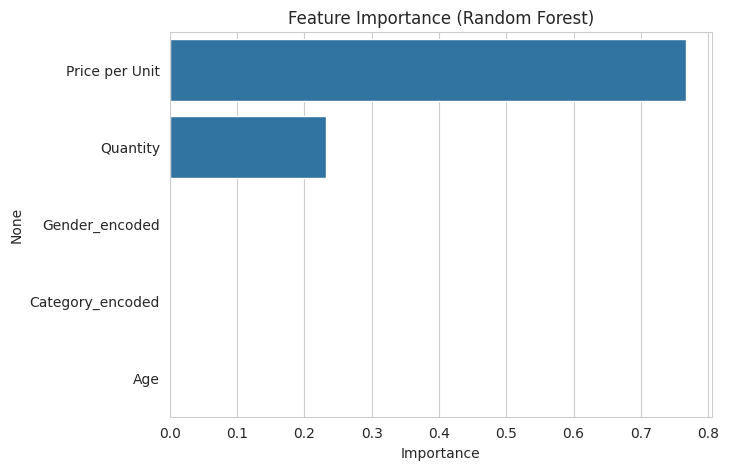

In [24]:
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()


This matches the EDA exactly: **Price per Unit** and **Quantity** dominate the prediction, together accounting for basically all of the model's decision making, while Age, Gender, and Category contribute almost nothing. In plain terms for this dataset, how much a customer spends is driven almost entirely by *what they bought and how many*, not by who they are.


## Phase 5: The Interactive GUI Application

Deploying the trained model into an interactive web interface.

**Instructions:**
- Import the interactive web interface library.
- Write a custom prediction function that takes user inputs, processes them, passes them to the trained model, and returns a prediction.
- Build and launch a live interactive web application interface allowing users to test predictions in real-time.


In [ ]:
!pip install gradio -q

import gradio as gr

# a little color-coding per category just for visual flair in the output card
category_colors = {
    'Beauty': '#e75480',
    'Clothing': '#4b8bf5',
    'Electronics': '#2ecc71'
}

def predict_total_amount(gender, age, category, quantity, price_per_unit):
    # turn the human-readable dropdown choices back into the encoded numbers
    # the model was actually trained on
    gender_encoded = le_gender.transform([gender])[0]
    category_encoded = le_category.transform([category])[0]

    input_df = pd.DataFrame([
        {
            'Gender_encoded': gender_encoded,
            'Age': age,
            'Category_encoded': category_encoded,
            'Quantity': quantity,
            'Price per Unit': price_per_unit
        }
    ])

    prediction = rf_model.predict(input_df)[0]
    color = category_colors.get(category, '#8e44ad')

    # returning styled HTML instead of plain text so the result pops visually
    result_html = f'''
    <div style="
        background: linear-gradient(135deg, {color}22, {color}55);
        border-left: 8px solid {color};
        border-radius: 12px;
        padding: 20px 25px;
        font-family: 'Segoe UI', sans-serif;
        text-align: center;
    ">
        <p style="margin:0; font-size:16px; color:#333;">Predicted Total Amount for a {category} purchase</p>
        <p style="margin:5px 0 0 0; font-size:36px; font-weight:800; color:{color};">
            ${prediction:,.2f}
        </p>
    </div>
    '''
    return result_html


# a warm, friendly built-in theme instead of the flat gradio default
theme = gr.themes.Soft(
    primary_hue="pink",
    secondary_hue="blue",
    neutral_hue="slate"
)

# extra CSS for a page-wide gradient background and softer card corners
custom_css = """
.gradio-container {
    background: linear-gradient(135deg, #fdf2f8 0%, #eef2ff 50%, #ecfdf5 100%);
}
#title_block h1 {
    background: linear-gradient(90deg, #e75480, #4b8bf5, #2ecc71);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-weight: 800;
}
.gr-button-primary {
    background: linear-gradient(90deg, #e75480, #ff8fab) !important;
    border: none !important;
}
"""

with gr.Blocks(theme=theme, css=custom_css) as demo:
    gr.Markdown(
        "# 🛍️ Retail Sales - Total Amount Predictor",
        elem_id="title_block"
    )
    gr.Markdown(
        "Tell us a bit about the customer and the purchase, and the model will "
        "predict how much the transaction is worth. Built on 1,000 real retail transactions."
    )

    with gr.Row():
        with gr.Column(scale=1):
            gender_input = gr.Radio(
                choices=list(le_gender.classes_), label="👤 Gender", value=list(le_gender.classes_)[0]
            )
            age_input = gr.Slider(
                minimum=int(df['Age'].min()), maximum=int(df['Age'].max()),
                step=1, value=int(df['Age'].mean()), label="🎂 Age"
            )
            category_input = gr.Radio(
                choices=list(le_category.classes_), label="🛍️ Product Category",
                value=list(le_category.classes_)[0]
            )
            quantity_input = gr.Slider(
                minimum=1, maximum=int(df['Quantity'].max()), step=1, value=1, label="📦 Quantity"
            )
            price_input = gr.Number(label="💵 Price per Unit", value=50)
            predict_btn = gr.Button("✨ Predict Total Amount", variant="primary")

        with gr.Column(scale=1):
            output_html = gr.HTML(label="Prediction")

    predict_btn.click(
        fn=predict_total_amount,
        inputs=[gender_input, age_input, category_input, quantity_input, price_input],
        outputs=output_html
    )

demo.launch(debug=True)

/tmp/ipykernel_1376/582838605.py:74: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme, css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5fa3808935761259b7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Phase 5: The Interactive GUI Application

The final step wraps the trained Random Forest model in a live, interactive web app using **Gradio**, so anyone can enter customer and purchase details and instantly get a predicted Total Amount with no code required.

### How it works
- The `predict_total_amount()` function takes the raw form inputs (Gender, Age, Product Category, Quantity, Price per Unit), encodes Gender and Category back into the numeric format the model was trained on (using the same `LabelEncoder`s from Phase 3), and passes them into `rf_model.predict()`.
- The result is returned as a styled HTML card rather than plain text, so the prediction is easy to read at a glance.

### Design choices
- **Theme:** `gr.themes.Soft` with a pink/blue palette, instead of Gradio's flat default grey which makes the app feel more like a customer facing tool than a debug form.
- **Background:** a soft page wide gradient (pink → blue → green) for visual warmth.
- **Gradient title text:** the header uses a CSS gradient clip so the title itself carries the same color scheme.
- **Color coded results:** the prediction card's color changes based on the selected Product Category (pink for Beauty, blue for Clothing, green for Electronics), giving instant visual feedback tied to the choice made.
- **Emoji labels:** each input field has a small emoji (👤 Gender, 🎂 Age, 🛍️ Category, 📦 Quantity, 💵 Price) to make the form feel friendlier and quicker to scan.
- **Layout:** built with `gr.Blocks` and a two column `gr.Row`, so inputs sit on the left and the prediction result sits clearly on the right, rather than stacking everything in one long column.

### Why this matters
None of this styling changes the underlying model or its predictions, it's a presentation layer on top of the same Random Forest from Phase 4. But for an end user (or a customer facing deployment), a clean, colorful, well labeled interface makes the tool feel trustworthy and easy to use, which is just as important as model accuracy when it comes to real world adoptions.
